In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project folder:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)

Project folder: /Users/komalgarg/PROJECTS/Customer-Churn-Analysis
Data folder: /Users/komalgarg/PROJECTS/Customer-Churn-Analysis/data


In [3]:
DB_PATH = DATA_DIR / "customer_churn.db" 
CSV_PATH = DATA_DIR / "customer_churn_merged_500_rows.csv" 

print("Database:", DB_PATH) 
print("CSV:", CSV_PATH)

Database: /Users/komalgarg/PROJECTS/Customer-Churn-Analysis/data/customer_churn.db
CSV: /Users/komalgarg/PROJECTS/Customer-Churn-Analysis/data/customer_churn_merged_500_rows.csv


In [4]:
# 1. Import Database / Data

In [5]:
db_path = DB_PATH

conn = sqlite3.connect(db_path)

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table' ;
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe from each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT *  FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created Dataframe: df_{table_name}")

# Print table names and column names
for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close Connection
conn.close()

Created Dataframe: df_db_customer
Created Dataframe: df_db_subscription
Created Dataframe: df_db_support

Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [6]:
# 2. Data Cleaning

In [7]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [9]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [10]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

In [11]:
#### a. rename column

In [12]:
# a. rename col - name to customer_name
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)

# Check
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob',
       'interests', 'pincode'],
      dtype='str')

In [13]:
#### b. Drop columns

In [14]:
# b. drop columns - interest and pincode
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name

# Check
df_db_customer.columns

Index(['customerid', 'customer_name', 'country', 'state', 'gender', 'dob'], dtype='str')

In [15]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [16]:
#### c. Change data type

In [17]:
# c. change data type - dob
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

# Check
df_db_customer['dob'].head()

0   1982-04-12
1   1995-11-23
2   1978-02-15
3   2001-08-30
4   1990-05-05
Name: dob, dtype: datetime64[us]

In [18]:
#### d. Data standardization

In [19]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [20]:
# d. data standardization - gender
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [21]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [22]:
#### e. Fix missing values

In [23]:
df_db_customer['country'].isna().sum()

np.int64(3)

In [24]:
# e. fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [25]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [26]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [27]:
df_db_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [28]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [29]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [30]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [31]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [32]:
# drop columns
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [33]:
# change data type to date - complaint_date

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [34]:
## 3. Feature Engineering & Data Analysis

In [35]:
#### Create a new col

In [36]:
# create a new col using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)
df_db_subscription['churn_flag'].head()

0    0
1    1
2    0
3    0
4    1
Name: churn_flag, dtype: int64

In [37]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [38]:
#### Merge Dataframes - JOINs

In [39]:
# first fix support table duplicates then merge
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [40]:
df_db_subscription.shape

(21, 12)

In [41]:
df.shape

(23, 20)

In [42]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 21
df_db_customer unique value: 21
df_db_support unique value: 7
df_db_support all value: 9


In [43]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [44]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [45]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [46]:
df_db_support['customerid'].size

7

In [47]:
# merge df
df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how= 'left')
            .merge(df_db_support, on = 'customerid', how= 'left') )

In [48]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [49]:
df.shape

(21, 21)

In [50]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [51]:
# Add Data
df_new = pd.read_csv(CSV_PATH)
df = pd.concat([df, df_new], ignore_index=True)
print("Data Inserted Successfully")
print(df.shape)

Data Inserted Successfully
(521, 25)


In [52]:
## Data Quality Check: Duplicate Customers

In [53]:
# Check for duplicate customer IDs

total_rows = len(df)
unique_customers = df['customerid'].nunique()
duplicate_rows = df['customerid'].duplicated().sum()
duplicate_customer_ids = (
    df.loc[df['customerid'].duplicated(keep=False), 'customerid']
      .nunique()
)

print("Total Rows:", total_rows)
print("Unique Customers:", unique_customers)
print("Duplicate Rows:", duplicate_rows)
print("Duplicate Customer IDs:", duplicate_customer_ids)

Total Rows: 521
Unique Customers: 507
Duplicate Rows: 14
Duplicate Customer IDs: 14


In [54]:
# Identify customers appearing more than once

duplicate_counts = (
    df['customerid']
    .value_counts()
    .rename_axis('customerid')
    .reset_index(name='row_count')
)

duplicate_customers = duplicate_counts[
    duplicate_counts['row_count'] > 1
]

duplicate_customers

,customerid,row_count
0,0002-ORFBO,2
1,0003-MKNFE,2
2,0004-TLHLJ,2
3,0011-IGKFF,2
4,0013-EXCHZ,2
5,0013-MHZWF,2
6,0013-SMEOE,2
7,0014-BMAQU,2
8,0015-UOCOJ,2
9,0016-QLJIS,2


In [55]:
# View all records for duplicated customers

duplicate_customer_ids = duplicate_customers['customerid']

duplicate_records = (
    df[df['customerid'].isin(duplicate_customer_ids)]
    .sort_values('customerid')
)

duplicate_records

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,customer_age,cancellation_month
0,0002-ORFBO,2021-03-15 00:00:00,Refferal,2025-03-15 00:00:00,Standard,Annual,NaT,NaN,13.99,627,...,Male,1982-04-12 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,Male,1982-04-12,NaN,0,NaN,NaN,2017.0,low,44.0,NaN
1,0003-MKNFE,2020-08-01 00:00:00,Paid,2024-08-01 00:00:00,Premium,Annual,2024-09-10 00:00:00,Switched to competitor,12.99,1150,...,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,Y,10.0,2.0,NaN,NaN,NaN,NaN
22,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,30.0,2024-09
2,0004-TLHLJ,2022-11-20 00:00:00,Organic,2025-11-20 00:00:00,Basic,Monthly,NaT,NaN,6.99,210,...,Female,1978-02-15 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,Female,1978-02-15,NaN,0,NaN,NaN,1402.0,low,48.0,NaN
3,0011-IGKFF,2019-05-10 00:00:00,Paid,2025-05-10 00:00:00,Premium,Annual,NaT,NaN,22.99,1725,...,Male,2001-08-30 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,Male,2001-08-30,NaN,0,NaN,NaN,2692.0,low,25.0,NaN
4,0013-EXCHZ,2023-01-05 00:00:00,Refferal,2024-01-05 00:00:00,Standard,Monthly,2024-02-28 00:00:00,Too expensive,13.99,195,...,Female,1990-05-05 00:00:00,2024-01-20 00:00:00,Y,20.0,1.0,NaN,NaN,NaN,NaN
25,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,36.0,2024-02


In [56]:
# Duplicate Customer Records

duplicate_customer_ids = (
    df['customerid']
    .value_counts()
    .loc[lambda x: x > 1]
    .index
)

duplicate_records = (
    df[df['customerid'].isin(duplicate_customer_ids)]
    .sort_values('customerid')
)

print("Duplicate Customer IDs:", len(duplicate_customer_ids))
print("Duplicate Records:", len(duplicate_records))

Duplicate Customer IDs: 14
Duplicate Records: 28


In [57]:
# Compare duplicate records by customer

comparison_columns = [
    'customerid',
    'subscription_start_date',
    'subscription_type',
    'plan_type',
    'contract_type',
    'cancellation_date',
    'monthly_charges',
    'cltv',
    'churn_flag',
    'customer_name',
    'country',
    'state',
    'gender',
    'dob',
    'complaint_date',
    'escalations',
    'csat_score',
    'complaint_count',
    'tenure_days',
    'churn_risk',
    'customer_age',
    'cancellation_month'
]

duplicate_records[comparison_columns]

,customerid,subscription_start_date,subscription_type,plan_type,contract_type,cancellation_date,monthly_charges,cltv,churn_flag,customer_name,...,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk,customer_age,cancellation_month
0,0002-ORFBO,2021-03-15 00:00:00,Refferal,Standard,Annual,NaT,13.99,627,0,keshav,...,Male,1982-04-12 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0002-ORFBO,2021-03-15,Refferal,Standard,Annual,NaN,13.99,627,0,keshav,...,Male,1982-04-12,NaN,0,NaN,NaN,2017.0,low,44.0,NaN
1,0003-MKNFE,2020-08-01 00:00:00,Paid,Premium,Annual,2024-09-10 00:00:00,12.99,1150,1,raghav,...,Male,1995-11-23 00:00:00,2024-08-28 00:00:00,Y,10.0,2.0,NaN,NaN,NaN,NaN
22,0003-MKNFE,2020-08-01,Paid,Premium,Annual,2024-09-10,12.99,1150,1,raghav,...,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high,30.0,2024-09
2,0004-TLHLJ,2022-11-20 00:00:00,Organic,Basic,Monthly,NaT,6.99,210,0,lalita,...,Female,1978-02-15 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,0004-TLHLJ,2022-11-20,Organic,Basic,Monthly,NaN,6.99,210,0,lalita,...,Female,1978-02-15,NaN,0,NaN,NaN,1402.0,low,48.0,NaN
3,0011-IGKFF,2019-05-10 00:00:00,Paid,Premium,Annual,NaT,22.99,1725,0,mohan,...,Male,2001-08-30 00:00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0011-IGKFF,2019-05-10,Paid,Premium,Annual,NaN,22.99,1725,0,mohan,...,Male,2001-08-30,NaN,0,NaN,NaN,2692.0,low,25.0,NaN
4,0013-EXCHZ,2023-01-05 00:00:00,Refferal,Standard,Monthly,2024-02-28 00:00:00,13.99,195,1,mira,...,Female,1990-05-05 00:00:00,2024-01-20 00:00:00,Y,20.0,1.0,NaN,NaN,NaN,NaN
25,0013-EXCHZ,2023-01-05,Refferal,Standard,Monthly,2024-02-28,13.99,195,1,mira,...,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high,36.0,2024-02


In [58]:
## Duplicate Resolution

# Duplicate customer IDs were identified after appending the additional dataset.
# Since the original merged dataset represents the primary customer records, 
# existing customer IDs from the additional dataset were excluded to maintain one record per customer.

In [59]:
# Separate original and appended records

original_rows = df.iloc[:21].copy()
appended_rows = df.iloc[21:].copy()

print("Original Rows:", len(original_rows))
print("Appended Rows:", len(appended_rows))

Original Rows: 21
Appended Rows: 500


In [60]:
# Keep only new customers from the appended dataset

original_customer_ids = set(original_rows['customerid'])

appended_new_customers = appended_rows[
    ~appended_rows['customerid'].isin(original_customer_ids)
].copy()

print("New Customers Added:", appended_new_customers['customerid'].nunique())

New Customers Added: 486


In [61]:
# Create final customer-level dataset

df = pd.concat(
    [original_rows, appended_new_customers],
    ignore_index=True
)

print("Final Rows:", len(df))
print("Unique Customers:", df['customerid'].nunique())

Final Rows: 507
Unique Customers: 507


In [62]:
# Final duplicate validation

duplicate_count = df['customerid'].duplicated().sum()

print("Final Rows:", len(df))
print("Unique Customers:", df['customerid'].nunique())
print("Duplicate Customer Rows:", duplicate_count)

Final Rows: 507
Unique Customers: 507
Duplicate Customer Rows: 0


In [63]:
# export dataframe to csv file
df.to_csv('exported_churn_data_.csv', index=False)

In [64]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'customer_age', 'cancellation_month'],
      dtype='str')

In [65]:
## Data Analysis

In [66]:
### A. Customer Overview

In [67]:
# 1. Total Customers

total_customers = df['customerid'].count()
print("Total Customers:", total_customers)

total_customers = df['customerid'].nunique()
print("Total Customers:", total_customers)

Total Customers: 507
Total Customers: 507


In [68]:
# 2. Churned Customers

churned_customers = df.loc[df['churn_flag'] == 1, 'customerid'].nunique()
print("Churned Customers:", churned_customers)

Churned Customers: 156


In [69]:
# 3. Churn Rate

churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  30.77 %


In [70]:
# 4. Retenion Rate

retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  69.23 %


In [71]:
# 5. Average Customer Age

df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

df['customer_age'] = (
    (pd.Timestamp.today().normalize() - df['dob']).dt.days / 365.25
).round()

avg_age = df['customer_age'].mean()

print("Average Customer Age:", round(avg_age, 1), "years")

Average Customer Age: 42.7 years


In [72]:
# Convert date columns to datetime

df['subscription_start_date'] = pd.to_datetime(
    df['subscription_start_date'],
    errors='coerce'
)

df['cancellation_date'] = pd.to_datetime(
    df['cancellation_date'],
    errors='coerce'
)

# Check datatypes
print(df[['subscription_start_date', 'cancellation_date']].dtypes)

subscription_start_date    datetime64[us]
cancellation_date          datetime64[us]
dtype: object


In [73]:
# 6. Average Customer Tenure
# count of days users has used our service : cancellation date else current date

today = pd.Timestamp.today().normalize()

end_date = df['cancellation_date'].fillna(today)

df['tenure_days'] = (
    end_date - df['subscription_start_date']
).dt.days

avg_tenure = df['tenure_days'].mean()

print("Average Customer Tenure:", round(avg_tenure, 0), "days")

Average Customer Tenure: 1455.0 days


In [74]:
### Insight

# The dataset contains 507 unique customers, with an overall churn rate of 30.77%. 
# The average customer age is approximately 42 years, while the average customer tenure is about 1,455 days.

In [75]:
### B. Churn Segmentation

In [76]:
# 7. Churn by Plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           37.22
1   Premium           23.89
2  Standard           28.97


In [77]:
### Insight

# Basic-plan customers show the highest observed churn rate at 37.22%, followed by Standard at 28.97% and Premium at 23.89%. 
# This indicates that churn varies across plan types in the analyzed dataset.

In [78]:
# 8. Churn by Contract Type

contract_churn = (
    df.groupby('contract_type')['churn_flag']
      .mean()
      .mul(100)
      .round(2)
      .reset_index(name='churn_rate_pct')
)

print(contract_churn)

  contract_type  churn_rate_pct
0        Annual           20.99
1       Monthly           39.77


In [79]:
### Insight

# Monthly-contract customers show a higher observed churn rate of 39.77% compared with 20.99% for annual-contract customers. 
# Contract type is therefore associated with a noticeable difference in observed churn levels.

In [80]:
# 9. Subscription Type Analysis

subscription_analysis = (
    df.groupby('subscription_type')
      .agg(
          churn_rate=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          customer_count=('customerid', 'nunique')
      )
      .reset_index()
)

subscription_analysis['churn_rate'] = (
    subscription_analysis['churn_rate'] * 100
).round(2)

subscription_analysis['total_revenue'] = (
    subscription_analysis['total_revenue'].round(2)
)

print(subscription_analysis)

  subscription_type  churn_rate  total_revenue  customer_count
0           Organic       26.90        2814.03             197
1              Paid       35.87        2549.16             184
2          Refferal       29.37        1754.74             126


In [81]:
### Insight

# Paid subscribers show the highest observed churn rate at 35.87%, compared with 29.37% for referral subscribers and 26.90% for organic subscribers. 
# The results indicate differences in churn behavior across subscription acquisition types.

In [82]:
# 10. State Analysis

state_analysis = (
    df.groupby('state')
      .agg(
          churn_rate=('churn_flag', 'mean'),
          total_revenue=('monthly_charges', 'sum'),
          customer_count=('customerid', 'nunique')
      ).reset_index()
)

state_analysis['churn_rate'] = (
    state_analysis['churn_rate'] * 100
).round(2)

state_analysis['total_revenue'] = (
    state_analysis['total_revenue'].round(2)
)

print(state_analysis)

            state  churn_rate  total_revenue  customer_count
0           Bihar       30.30         419.67              33
1           Delhi       24.24         463.67              33
2         Gujarat       38.10         293.79              21
3         Haryana       37.50         463.68              32
4       Karnataka       51.28         528.61              39
5       Kathmandu        0.00          20.98               2
6          Kerala       20.69         368.71              29
7     Maharashtra       34.15         595.59              41
8       Meghalaya       30.77         350.74              26
9        Nagaland       25.00         519.64              36
10         Punjab       35.29         451.66              34
11      Rajasthan       28.57         610.58              42
12     Tamil Nadu       30.56         518.64              36
13      Telangana       26.32         531.62              38
14  Uttar Pradesh       18.18         547.67              33
15    West Bengal       

In [83]:
### Insight

# Observed churn rates vary considerably across states. 
# Karnataka has the highest observed churn rate among the larger state groups at 51.28%, 
# while Uttar Pradesh and Kerala show lower observed churn rates of 18.18% and 20.69%, respectively. 
# State-level differences should be interpreted alongside customer volume.

In [84]:
# 11. Churn by Gender

gender_churn = (
    df.groupby('gender')['churn_flag']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(gender_churn)

gender
Male      31.007752
Female    30.522088
Name: churn_flag, dtype: float64


In [85]:
### C. Revenue & Financial Impact

In [86]:
# 12. Average Revenue Per User (ARPU)

arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  14.04


In [87]:
# 13. Total Monthly Revenue

total_monthly_revenue = df['monthly_charges'].sum()
print("Total Monthly Revenue:",round(total_monthly_revenue, 2))

Total Monthly Revenue: 7117.93


In [88]:
# 14. Monthly Revenue at risk - revenue lost from churned users

monthly_revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Monthly Revenue at Risk:", round(monthly_revenue_at_risk, 2))

Monthly Revenue at Risk: 2026.44


In [89]:
### Insight

# The average revenue per customer is 14.04, with total monthly revenue of 7,117.93 across the analyzed customer base. 
# Monthly revenue at risk is estimated at 2,026.44 based on the monthly charges of churned customers.

In [90]:
# 15. Revenue Churn Rate

revenue_churn_rate = (
    df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
    / df['monthly_charges'].sum()
) * 100

print("Revenue Churn Rate:", round(revenue_churn_rate, 2), "%")

Revenue Churn Rate: 28.47 %


In [91]:
### Insight

# The revenue churn rate is 28.47%, indicating that the share of monthly revenue 
# associated with churned customers is substantial relative to the overall customer churn rate of 30.77%.

In [92]:
### D. Customer Value

In [93]:
# 16. Average Customer Lifetime Value (CLTV)

avg_cltv = df['cltv'].mean()
print("Average CLTV:",round(avg_cltv, 2))

Average CLTV: 794.82


In [94]:
# 17. Average CLTV of Churned Customers

churned_cltv = (df.loc[df['churn_flag'] == 1, 'cltv'].mean())
print("Average CLTV of Churned Customers:",round(churned_cltv, 2))

Average CLTV of Churned Customers: 433.63


In [95]:
# 18. CLTV at Risk

cltv_at_risk = (df.loc[df['churn_flag'] == 1, 'cltv'].sum())
print("CLTV at Risk:", round(cltv_at_risk, 2))

CLTV at Risk: 67646


In [96]:
### Insight

# The average customer lifetime value (CLTV) is 794.82, while the average CLTV among churned customers is 433.63. 
# The estimated CLTV associated with churned customers is 67,646, highlighting the potential customer-value impact of churn.

In [97]:
### E. Customer Support

In [98]:
# 19. Esclation Rate

escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  0.79 %


In [99]:
# 20. Average Complaints per Supported Customer

supported_customers = df['complaint_count'].notna().sum()

total_complaints = df['complaint_count'].sum()

avg_complaints = (total_complaints / supported_customers)

print("Average Complaints per Supported Customer:",round(avg_complaints, 2))

Average Complaints per Supported Customer: 2.21


In [100]:
### Insight

# Customers with support interactions average approximately 2.21 complaints per supported customer. 
# Comparing complaint distribution across churn status can help identify whether higher support activity is associated with customer churn.

In [101]:
# 21. Average CSAT Score
avg_csat = df['csat_score'].mean()
print("Average CSAT Score:", round(avg_csat, 2))

Average CSAT Score: 54.67


In [102]:
### Insight

# The average customer satisfaction score is 54.67. 
# Satisfaction levels provide additional context for understanding customer experience and their relationship with observed churn.

In [103]:
# 22. Churn by CSAT Group

df['csat_group'] = pd.cut(
    df['csat_score'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)

churn_by_csat = (df.groupby('csat_group', observed=True)['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_csat)

  csat_group  churn_rate_pct
0        Low          100.00
1     Medium           75.82
2       High            1.39


In [104]:
### Insight

# Churn rates differ substantially across CSAT groups in the analyzed dataset. 
# Customers in the Low and Medium satisfaction groups show considerably higher observed churn than customers in the High satisfaction group, 
# indicating a strong association between satisfaction level and churn.

In [105]:
# 23. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.13


In [106]:
### Insight

# The correlation between support escalations and churn indicates 
# the strength and direction of their linear association in the analyzed dataset. 
# Correlation should be interpreted as an association rather than evidence that escalations directly cause churn.

In [107]:
# 24. Create Churn Risk Categories

conditions = [
    df['churn_score'] < 50,
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    df['churn_score'] >= 70
]

choices = ['low','medium','high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [108]:
# 25. Churn Risk Distribution

risk_distribution = (df['churn_risk'].value_counts().reindex(['low', 'medium', 'high']))

print(risk_distribution)

churn_risk
low       348
medium     43
high      116
Name: count, dtype: int64


In [109]:
### Insight

# The churn-risk segmentation classifies 348 customers as low risk, 43 as medium risk, and 116 as high risk. 
# This segmentation provides a practical way to identify customers who may require greater retention attention.

In [110]:
# 26. High-Risk Customers

high_risk_customers = (
    df['churn_risk'] == 'high'
).sum()

print(
    "High-Risk Customers:",
    high_risk_customers
)

High-Risk Customers: 116


In [111]:
### Insight

# A total of 116 customers are classified as high churn risk. 
# These customers represent an important segment for monitoring 
# because their predicted risk is substantially higher than that of the low- and medium-risk groups.

In [112]:
# 27. Monthly Revenue at High Risk

high_risk_revenue = (
    df.loc[
        df['churn_risk'] == 'high',
        'monthly_charges'
    ].sum()
)

print(
    "Monthly Revenue at High Risk:",
    round(high_risk_revenue, 2)
)

Monthly Revenue at High Risk: 1477.84


In [113]:
### Insight

# High-risk customers are associated with approximately 1,477.84 in monthly charges. 
# This represents the monthly revenue exposure within the high-risk customer segment.

In [114]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'customer_age', 'cancellation_month',
       'csat_group'],
      dtype='str')

In [115]:
## 4. Visualization using Matplotlib

In [116]:
df_visual = df.copy()

In [117]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'customer_age', 'cancellation_month',
       'csat_group'],
      dtype='str')

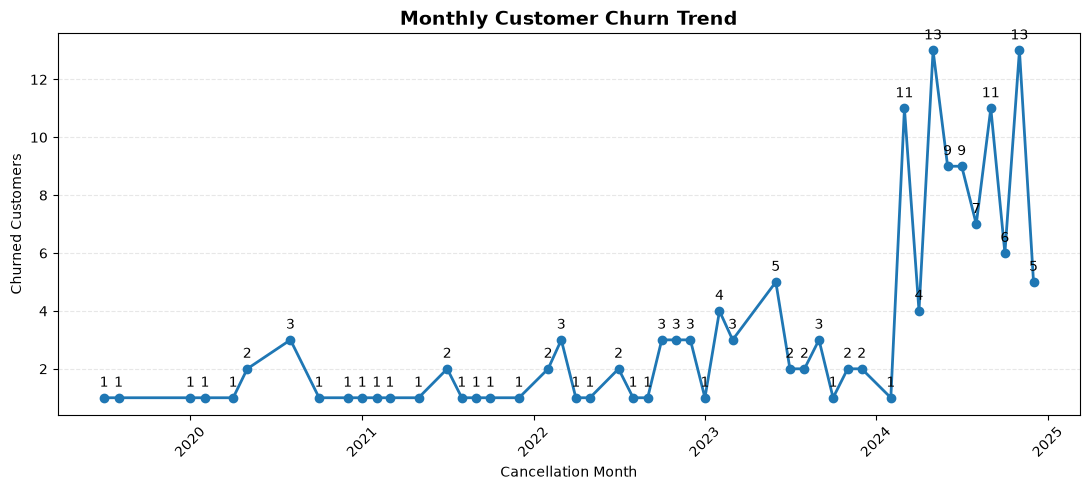

In [118]:
# 4.1 Monthly Customer Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = (
    df_visual['cancellation_date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

churn_trend = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
    .sort_index()
)

plt.figure(figsize=(11, 5))

plt.plot(
    churn_trend.index,
    churn_trend.values,
    marker='o',
    linewidth=2
)

# Data labels
for x, y in zip(churn_trend.index, churn_trend.values):
    plt.annotate(
        str(y),
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center'
    )

plt.title(
    'Monthly Customer Churn Trend',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Cancellation Month')
plt.ylabel('Churned Customers')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("../visuals/4.1 Monthly_Customer_Churn_Trend_(Time_Series_KPI).png", dpi=300, bbox_inches="tight")
plt.show()

In [119]:
### Insight

# Monthly churn shows variation over time, with some months recording higher numbers of customer cancellations than others. 
# This trend helps identify periods where customer retention may require closer monitoring.

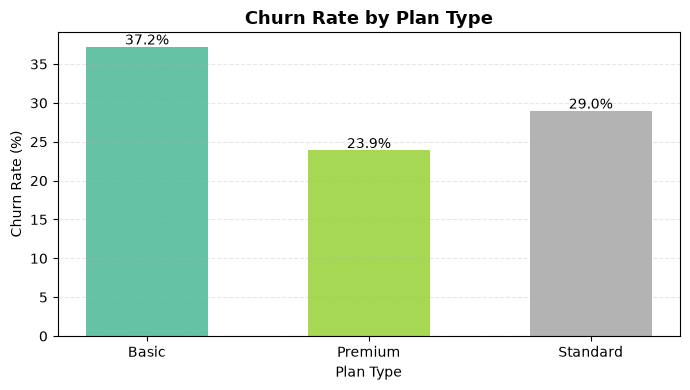

In [120]:
# 4.2 Churn Rate by Plan Type

churn_plan = (
    df_visual.groupby('plan_type')['churn_flag']
    .mean()
    .mul(100)
)

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7, 4))

bars = plt.bar(
    churn_plan.index,
    churn_plan.values,
    color=colors,
    width=0.55
)

plt.title('Churn Rate by Plan Type', fontweight='bold', fontsize=13)
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
# Values on top of bars
for bar, value in zip(bars, churn_plan.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../visuals/4.2 Churn_Rate_by_Plan_Type.png", dpi=300, bbox_inches="tight")
plt.show()

In [121]:
### Insight

# Basic-plan customers have the highest observed churn rate at 37.22%, while Premium-plan customers have the lowest at 23.89%. 
# The difference suggests that observed churn varies across customer plan types.

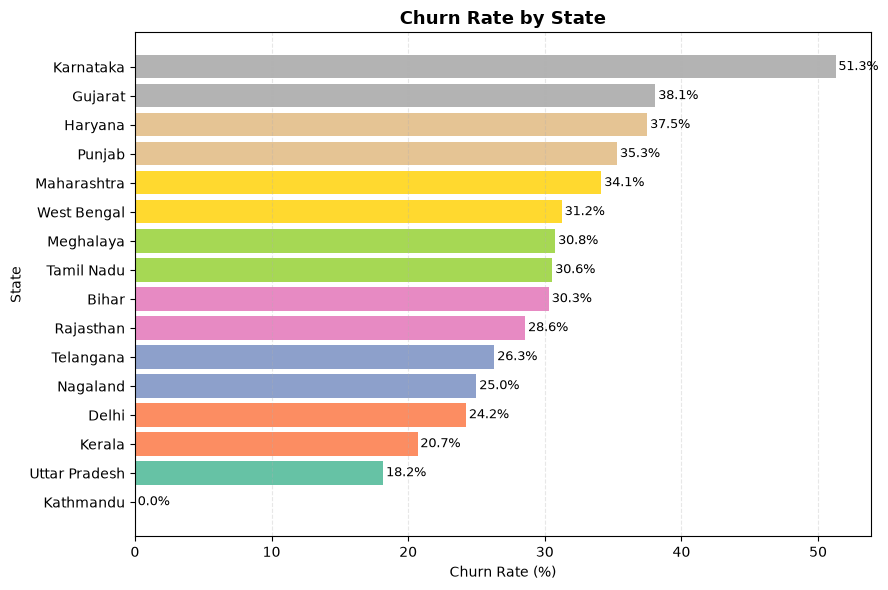

In [122]:
# 4.3 Churn Rate by State

churn_state = (
    df_visual.groupby('state')['churn_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    churn_state.index,
    churn_state.values,
    color=plt.cm.Set2(np.linspace(0, 1, len(churn_state)))
)

plt.title('Churn Rate by State', fontsize=13, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('State')

for bar, value in zip(bars, churn_state.values):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        fontsize=9
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/4.3 Churn_Rate_by_State.png", dpi=300, bbox_inches="tight")
plt.show()

In [123]:
### Insight

# Churn rates vary across states, indicating differences in observed customer retention patterns by geographic segment. 
# These differences should be considered together with the number of customers in each state to avoid overinterpreting smaller groups.

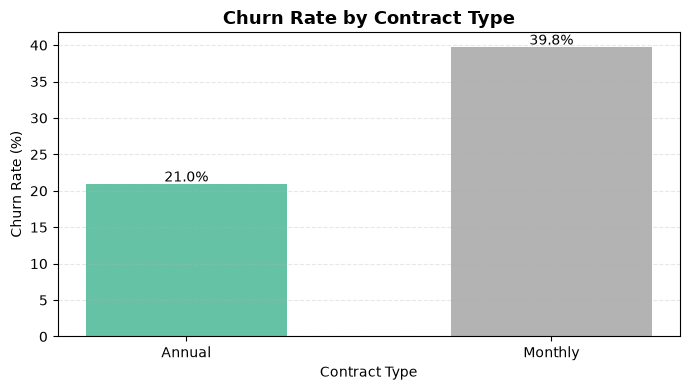

In [124]:
# 4.4 Churn Rate by Contract Type

churn_contract = (
    df_visual.groupby('contract_type')['churn_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(7, 4))

bars = plt.bar(
    churn_contract.index,
    churn_contract.values,
    width=0.55,
    color=plt.cm.Set2(np.linspace(0, 1, len(churn_contract)))
)

plt.title('Churn Rate by Contract Type',
          fontsize=13, fontweight='bold')

plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, churn_contract.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/4.4 Churn_Rate_by_Contract_Type.png", dpi=300, bbox_inches="tight")
plt.show()

In [125]:
### Insight

# Monthly-contract customers have a higher observed churn rate of 39.77% compared with 20.99% for annual-contract customers. 
# This shows a clear difference in observed churn across contract types within the analyzed dataset.

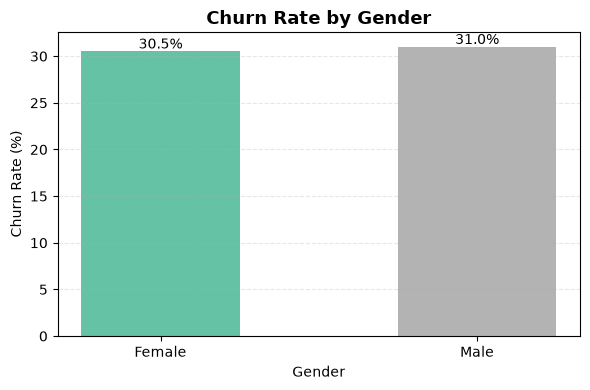

In [126]:
# 4.5 Churn Rate by Gender

churn_gender = (
    df_visual.groupby('gender')['churn_flag']
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    churn_gender.index,
    churn_gender.values,
    width=0.5,
    color=plt.cm.Set2(np.linspace(0, 1, len(churn_gender)))
)

plt.title('Churn Rate by Gender',
          fontsize=13, fontweight='bold')

plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')

for bar, value in zip(bars, churn_gender.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.1f}%',
        ha='center'
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/4.5 Churn_Rate_by_Gender.png", dpi=300, bbox_inches="tight")
plt.show()

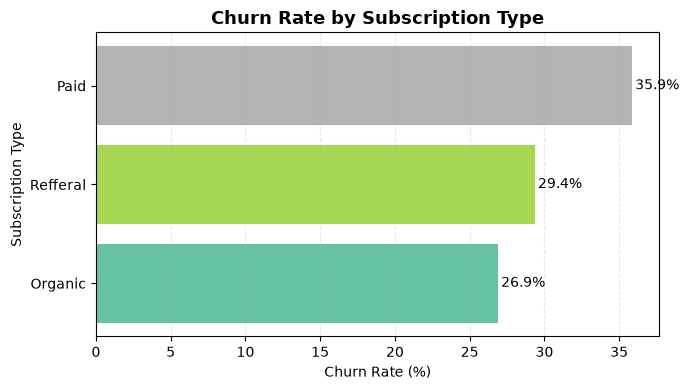

In [127]:
# 4.6 Churn Rate by Subscription Type

churn_subscription = (
    df_visual.groupby('subscription_type')['churn_flag']
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(7, 4))

bars = plt.barh(
    churn_subscription.index,
    churn_subscription.values,
    color=plt.cm.Set2(np.linspace(0, 1, len(churn_subscription)))
)

plt.title('Churn Rate by Subscription Type',
          fontsize=13, fontweight='bold')

plt.xlabel('Churn Rate (%)')
plt.ylabel('Subscription Type')

for bar, value in zip(bars, churn_subscription.values):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/4.6 Churn_Rate_by_Subscription_Type.png", dpi=300, bbox_inches="tight")
plt.show()

In [128]:
### Insight

# Paid subscribers show the highest observed churn rate at 35.87%, followed by referral subscribers at 29.37% 
# and organic subscribers at 26.90%. 
# This highlights differences in observed churn across subscription acquisition types.

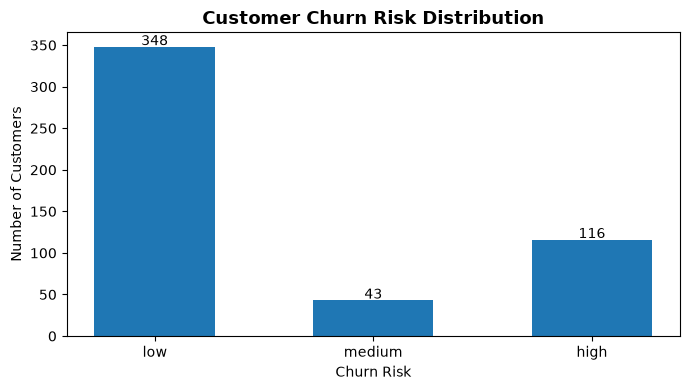

In [129]:
# 4.7 Customer Churn Risk Distribution

risk_counts = (
    df_visual['churn_risk']
    .value_counts()
    .reindex(['low', 'medium', 'high'])
)

plt.figure(figsize=(7, 4))

bars = plt.bar(
    risk_counts.index,
    risk_counts.values,
    width=0.55
)

plt.title(
    'Customer Churn Risk Distribution',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Churn Risk')
plt.ylabel('Number of Customers')

for bar, value in zip(bars, risk_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(value),
        ha='center'
    )

plt.tight_layout()
plt.savefig("../visuals/4.7 Customer_Churn_Risk_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [130]:
### Insight

# The churn-risk distribution contains 348 low-risk, 43 medium-risk, and 116 high-risk customers. 
# The segmentation provides a clear view of the size of each risk group and 
# helps identify the customer population requiring closer monitoring.

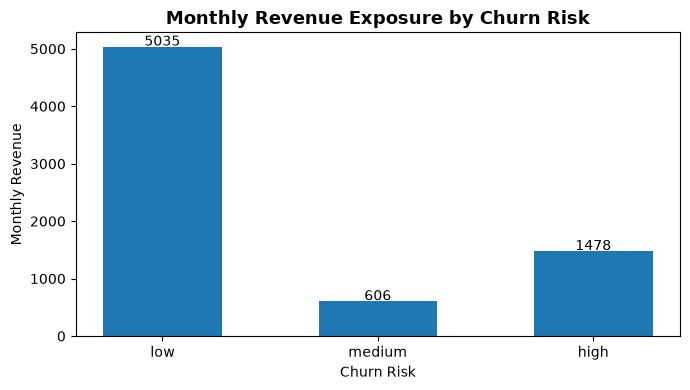

In [131]:
# 4.8 Monthly Revenue Exposure by Churn Risk

risk_revenue = (
    df_visual.groupby('churn_risk')['monthly_charges']
    .sum()
    .reindex(['low', 'medium', 'high'])
)

plt.figure(figsize=(7, 4))

bars = plt.bar(
    risk_revenue.index,
    risk_revenue.values,
    width=0.55
)

plt.title(
    'Monthly Revenue Exposure by Churn Risk',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Churn Risk')
plt.ylabel('Monthly Revenue')

for bar, value in zip(bars, risk_revenue.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{value:.0f}',
        ha='center'
    )

plt.tight_layout()
plt.savefig("../visuals/4.8 Monthly_Revenue_Exposure_by_Churn_Risk.png", dpi=300, bbox_inches="tight")
plt.show()

In [132]:
### Insight

# High-risk customers account for approximately 1,477.84 in monthly charges. 
# This highlights the financial exposure associated with the high-risk customer segment in the analyzed dataset.

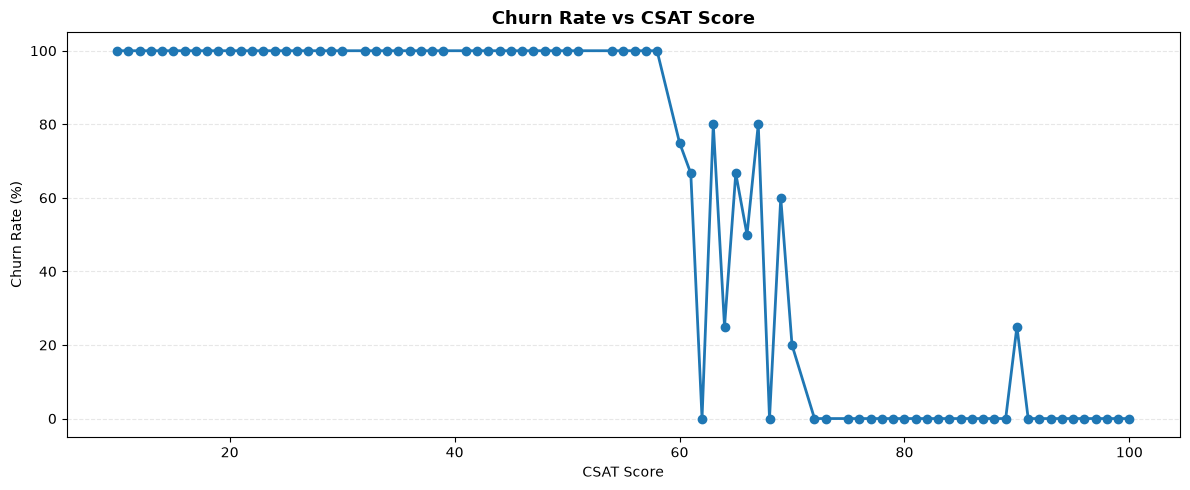

In [133]:
# 4.9 Churn Rate vs CSAT Score

csat_churn = (
    df_visual.groupby('csat_score')['churn_flag']
    .mean()
    .mul(100)
)

plt.figure(figsize=(12, 5))

plt.plot(
    csat_churn.index,
    csat_churn.values,
    marker='o',
    linewidth=2
)

plt.title('Churn Rate vs CSAT Score',
          fontsize=13, fontweight='bold')

plt.xlabel('CSAT Score')
plt.ylabel('Churn Rate (%)')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/4.9 Churn_Rate_vs_CSAT_Score.png", dpi=300, bbox_inches="tight")
plt.show()

In [134]:
## Visulaization using Seaborn

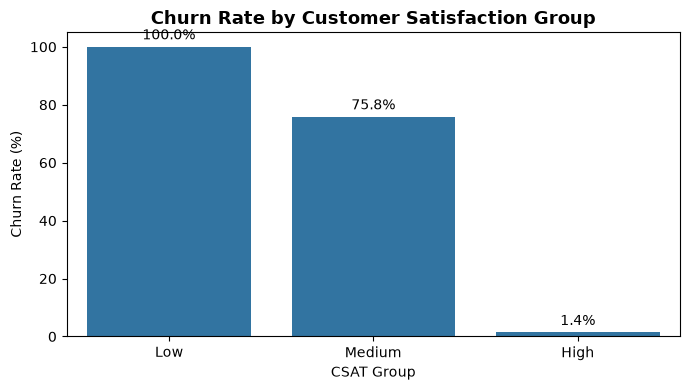

In [135]:
# 4.10 Churn Rate by CSAT Group

csat_churn = (
    df_visual.groupby('csat_group', observed=True)['churn_flag']
    .mean()
    .mul(100)
    .reset_index(name='churn_rate')
)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=csat_churn,
    x='csat_group',
    y='churn_rate'
)

plt.title(
    'Churn Rate by Customer Satisfaction Group',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('CSAT Group')
plt.ylabel('Churn Rate (%)')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.tight_layout()
plt.savefig("../visuals/4.10 Churn_Rate_by_CSAT_Group.png", dpi=300, bbox_inches="tight")
plt.show()

In [136]:
### Insight

# Churn varies substantially across customer satisfaction groups. 
# Low- and Medium-CSAT customers show much higher observed churn than High-CSAT customers, 
# indicating a strong association between customer satisfaction and churn in the analyzed dataset.

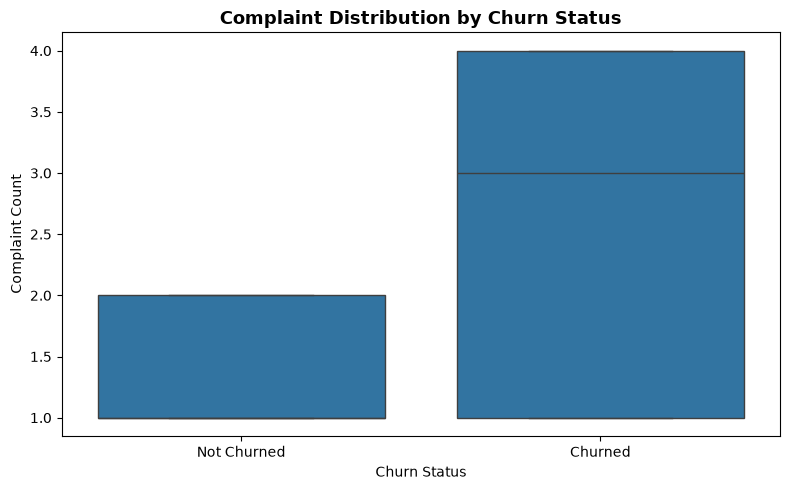

In [137]:
# 4.11 Complaints vs Churn Status

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_visual,
    x='churn_flag',
    y='complaint_count'
)

plt.title(
    'Complaint Distribution by Churn Status',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Churn Status')
plt.ylabel('Complaint Count')

plt.xticks(
    [0, 1],
    ['Not Churned', 'Churned']
)

plt.tight_layout()
plt.savefig("../visuals/4.11 Complaint_Distribution_by_Churn_Status.png", dpi=300, bbox_inches="tight")
plt.show()

In [138]:
### Insight

# The distribution of complaint counts differs between churned and non-churned customers. 
# Comparing these distributions helps assess whether higher support activity is associated with different churn patterns.

In [139]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [140]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'customer_age', 'cancellation_month',
       'csat_group'],
      dtype='str')

In [141]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str


In [142]:
# Method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'medium', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [143]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [144]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


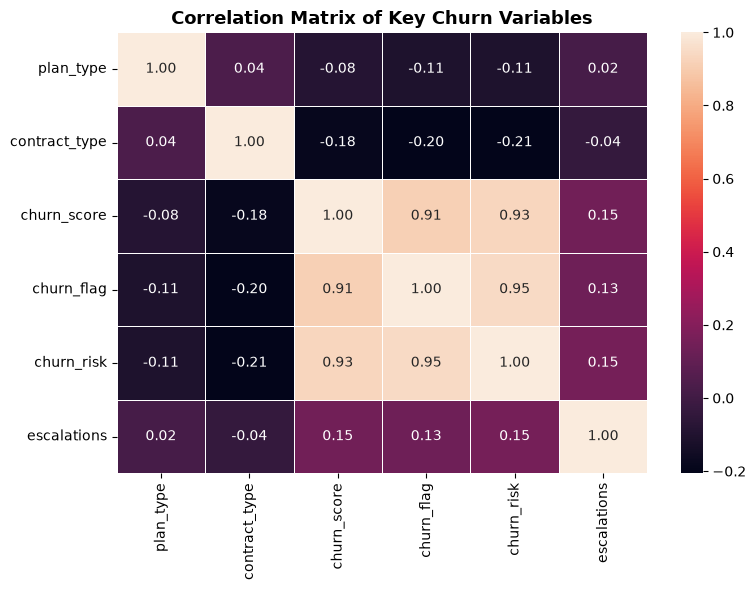

In [145]:
# 4.12 Correlation Heatmap (correlation matrix)

plt.figure(figsize=(8, 6))

corr_matrix = df_encoded.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Matrix of Key Churn Variables',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig("../visuals/4.12 Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [146]:
### Insight

# The correlation matrix provides an overview of relationships among selected numerical and encoded churn variables. 
# Stronger correlations can highlight variables that may warrant further investigation, 
# but correlation does not establish a causal relationship.

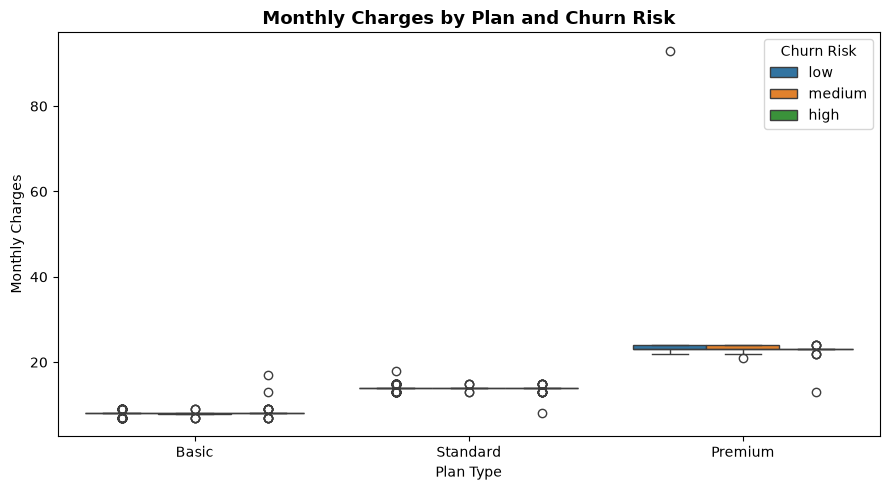

In [147]:
# 4.13 Monthly Charges by Plan and Churn Risk

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='churn_risk',
    order=['Basic', 'Standard', 'Premium'],
    hue_order=['low', 'medium', 'high']
)

plt.title(
    'Monthly Charges by Plan and Churn Risk',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Plan Type')
plt.ylabel('Monthly Charges')

plt.legend(title='Churn Risk')

plt.tight_layout()
plt.savefig("../visuals/4.13 Monthly_Charges_by_Plan and Churn_Risk.png", dpi=300, bbox_inches="tight")
plt.show()

In [148]:
### Insight

# Monthly charges vary across plan types and churn-risk groups. 
# The visualization helps compare how customer spending levels are distributed within different churn-risk segments.

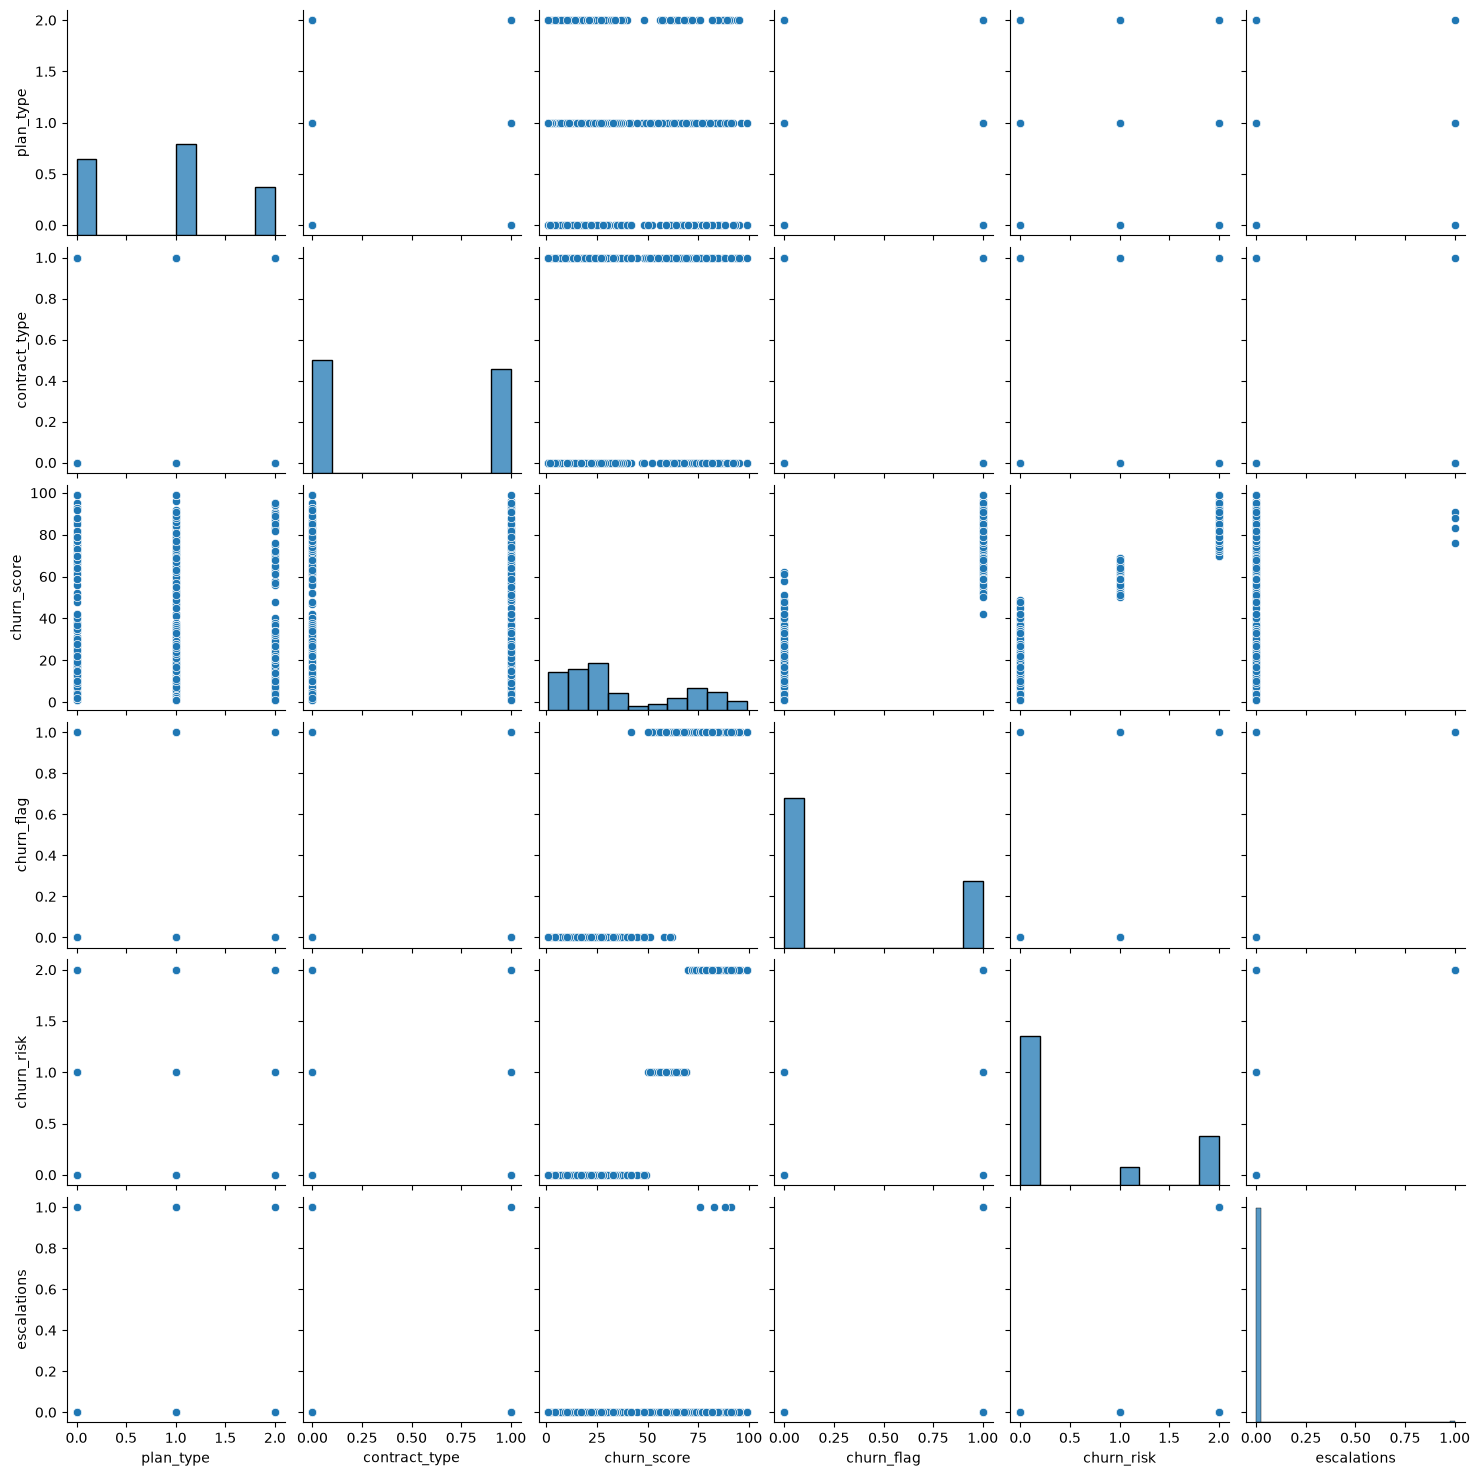

In [149]:
# 4.14 pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [150]:
## Pivot table

In [151]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.372222
Premium,0.238938
Standard,0.289720


In [152]:
plan_pivot = pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

plan_pivot['churn_flag'] = (
    plan_pivot['churn_flag'] * 100
).round(2)

plan_pivot.rename(
    columns={
        'monthly_charges': 'Total Monthly Revenue',
        'customerid': 'Customer Count',
        'churn_flag': 'Churn Rate (%)'
    },
    inplace=True
)

plan_pivot

,Churn Rate (%),Customer Count,Total Monthly Revenue
plan_type,,,
Basic,37.22,180,1451.20
Premium,23.89,113,2666.87
Standard,28.97,214,2999.86


In [153]:
### Insight

# The pivot table provides a consolidated comparison of customer count, total monthly revenue, and churn rate across plan types. 
# Basic-plan customers have the highest observed churn rate, 
# while Premium-plan customers have the lowest observed churn rate among the three plans.

In [154]:
## Key Business Insights

#- The overall customer churn rate is 30.77% across 507 unique customers.
#- Monthly-contract customers show a substantially higher observed churn rate (39.77%) than annual-contract customers (20.99%).
#- Basic-plan customers have the highest observed churn rate (37.22%), while Premium-plan customers have the lowest (23.89%).
#- Paid subscribers show the highest observed churn rate (35.87%) among the subscription types analyzed.
#- Monthly revenue at risk from churned customers is approximately 2,026.44.
#- A total of 116 customers are classified as high churn risk, representing approximately 1,477.84 in monthly charges.
#- Customer satisfaction shows a strong association with churn, with substantially higher observed churn among Low- and Medium-CSAT groups.

In [155]:
## 7. Conclusion

## This analysis provides an end-to-end view of customer churn by combining customer, subscription, revenue, support, satisfaction, 
# and churn-risk data. The analysis identifies important differences in 
# observed churn across contract types, plan types, subscription types, and customer satisfaction groups.

## The results can help a business focus further retention analysis on high-risk customers, 
# understand segments with higher observed churn, and quantify the potential revenue exposure associated with customer churn.